# Лабораторная работа 10

Тема: **Рекуррентные сети (LSTM/GRU) для классификации текстов в PyTorch**  
Цель: реализовать полный цикл решения задачи бинарной классификации текстов с помощью LSTM‑модели: от токенизации и построения словаря до обучения, валидации и анализа ошибок.

> Этот ноутбук оформлен как практическое задание.  
> Код даёт каркас, но основная часть баллов — за ваши собственные эксперименты и ваши пояснения.  
> Если вы попытаетесь автоматически сгенерировать весь текст отчёта, это будет заметно по стилю и несоответствию реальным графикам и числам.


## 1. Ваше исходное понимание задачи (обязательная текстовая часть)

Перед запуском кода зафиксируйте свои текущие представления (6–10 предложений):

1. Чем классификация текстов отличается от задач на изображения и табличные данные, с которыми вы уже работали.  
2. Зачем в текстовых задачах использовать рекуррентные сети (LSTM/GRU), а не просто среднее эмбеддингов слов с подачей в MLP.  
3. Как вы ожидаете, что **длина** текста и **порядок слов** повлияют на качество модели.

Пишите на своём языке, без попытки сделать "идеальное определение".


In [ ]:
intro_text = """1. Классификация текстов отличается от задач с изображениями и табличными данными тем,что текст это последовательность слов, где важен порядок и контекст. В картинках работали с пикселями и пространственными признаками, а в таблицах с фиксированными признаками, а в тексте признаки нужно ещё извлекать из самих слов и их сочетаний.
2. Я думаю, что рекуррентные сети вроде LSTM или GRU нужны потому, что они умеют учитывать последовательность и помнить предыдущие слова. Если просто взять среднее эмбеддингов и подать в MLP, то информация о порядке слов теряется, и модель может не уловить смысл фразы.
3.Длина текста, скорее всего, влияет на качество. Слишком короткие тексты могут не содержать достаточно информации, а слишком длинные сложнее обрабатывать и модель может забывать начало. Порядок слов тоже важен, потому что одни и те же слова в разном порядке могут означать разное.В целом я ожидаю, что модели типа LSTM/GRU будут работать лучше, чем простой MLP,особенно на более длинных и сложных текстах."""
print(intro_text)

1. Классификация текстов отличается от задач с изображениями и табличными данными тем,что текст это последовательность слов, где важен порядок и контекст. В картинках работали с пикселями и пространственными признаками, а в таблицах с фиксированными признаками, а в тексте признаки нужно ещё извлекать из самих слов и их сочетаний.
2. Я думаю, что рекуррентные сети вроде LSTM или GRU нужны потому, что они умеют учитывать последовательность и помнить предыдущие слова. Если просто взять среднее эмбеддингов и подать в MLP, то информация о порядке слов теряется, и модель может не уловить смысл фразы.
3.Длина текста, скорее всего, влияет на качество. Слишком короткие тексты могут не содержать достаточно информации, а слишком длинные сложнее обрабатывать и модель может забывать начало. Порядок слов тоже важен, потому что одни и те же слова в разном порядке могут означать разное.В целом я ожидаю, что модели типа LSTM/GRU будут работать лучше, чем простой MLP,особенно на более длинных и сложных 

## 2. Импорт библиотек и настройка среды

Загрузим необходимые библиотеки, зафиксируем зерно случайности и определим устройство (`cpu` или `cuda`).


In [9]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 11
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Пример простого текстового датасета

Для примера используем небольшой игрушечный датасет коротких предложений на английском с метками `0/1` (негатив/позитив).  
В **своей** лабораторной вы должны будете взять более содержательный и шумный датасет (реальные отзывы, комментарии и т.п.) - выберите какой-нибудь объект (фильм на кинопоиске, товар на озоне/вб, заведение на яндекс картах), скопируйте о нем отзывы, переведите на английский, раскидайте по  двум классам. Свой датасет соберите в отдельной новой ячейке.


In [ ]:
positive_sentences = [
    "I really liked this movie",
    "This film was great and inspiring",
    "What a fantastic experience",
    "I enjoyed every minute of it",
    "The actors did an amazing job",
    "Brilliant story and good pacing",
    "I would definitely watch it again",
    "It was funny and heartwarming",
    "A very beautiful and touching film",
    "Absolutely loved the characters"
]

negative_sentences = [
    "I really hated this movie",
    "This film was boring and slow",
    "What a terrible experience",
    "I regretted every minute of it",
    "The actors did a very bad job",
    "Awful story and strange pacing",
    "I would never watch it again",
    "It was dull and annoying",
    "A very ugly and pointless film",
    "Absolutely disliked the characters"
]

texts = positive_sentences + negative_sentences
labels = [1] * len(positive_sentences) + [0] * len(negative_sentences)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(df.head())
print("Размер датасета:", df.shape)
print("Распределение классов:\n", df["label"].value_counts())

                                text  label
0       I enjoyed every minute of it      1
1    Brilliant story and good pacing      1
2          I really hated this movie      0
3  I would definitely watch it again      1
4      The actors did a very bad job      0
Размер датасета: (20, 2)
Распределение классов:
 label
1    10
0    10
Name: count, dtype: int64


### Ваши замечания по датасету (обязательная мини‑секция)

Опишите (3–5 предложений):
- насколько базовый набор похож/не похож на реальные отзывы;  
- какие особенности реальных текстов в нем отсутствуют (длина, сленг, опечатки, смешение языков и т.п.);
- как эти отличия могут повлиять на результаты модели.


In [ ]:
data_comment = """Этот датасет сильно отличается от реальных отзывов, все предложения короткие, грамматически правильные, но в реальности тексты часто длиннее, содержат ошибки, сокращения.
Также здесь очень чёткое разделение на позитив и негатив, а в настоящих отзывах часто встречаются смешанные мнения(например, что-то понравилось, а что-то нет).
Из-за этого модель на таком датасете будет обучаться очень легко и показывать завышенные результаты. При переходе к реальным данным качество, скорее всего, упадёт, потому что задача станет сложнее и не такой идеальной."""
print(data_comment)

Этот датасет сильно отличается от реальных отзывов, все предложения короткие, грамматически правильные, но в реальности тексты часто длиннее, содержат ошибки, сокращения.
Также здесь очень чёткое разделение на позитив и негатив, а в настоящих отзывах часто встречаются смешанные мнения(например, что-то понравилось, а что-то нет).
Из-за этого модель на таком датасете будет обучаться очень легко и показывать завышенные результаты. При переходе к реальным данным качество, скорее всего, упадёт, потому что задача станет сложнее и не такой идеальной.


## 4. Токенизация, словарь и паддинг

Сделаем простую токенизацию:
- приведём текст к нижнему регистру;
- удалим лишние символы;
- разобьём строку на токены по пробелам.

Затем построим словарь и приведём все последовательности к одинаковой длине `max_len` с помощью паддинга.


In [11]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

my_df["tokens"] = my_df["text"].apply(simple_tokenize)
print(my_df[["text", "tokens"]].head())

                                text                                    tokens
0  I am satisfied with this purchase  [i, am, satisfied, with, this, purchase]
1   The food was delicious and fresh   [the, food, was, delicious, and, fresh]
2        I did not like this product        [i, did, not, like, this, product]
3      Service was friendly and fast       [service, was, friendly, and, fast]
4     Terrible product for the price      [terrible, product, for, the, price]


In [12]:
# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in my_df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

my_word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    my_word2idx[w] = len(my_word2idx)

my_idx2word = {idx: w for w, idx in my_word2idx.items()}

print("Размер словаря:", len(my_word2idx))
print("Первые элементы словаря:", list(my_word2idx.items())[:10])

Размер словаря: 59
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('and', 2), ('the', 3), ('was', 4), ('i', 5), ('this', 6), ('product', 7), ('very', 8), ('am', 9)]


In [13]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

my_df["encoded"] = my_df["tokens"].apply(lambda t: encode_tokens(t, my_word2idx))
print(my_df[["tokens", "encoded"]].head())

lengths = my_df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
my_max_len = int(lengths.max())  # для примера берём максимум
print("my_max_len =", my_max_len)

                                     tokens                encoded
0  [i, am, satisfied, with, this, purchase]  [5, 9, 29, 10, 6, 11]
1   [the, food, was, delicious, and, fresh]  [3, 12, 4, 30, 2, 31]
2        [i, did, not, like, this, product]  [5, 32, 13, 33, 6, 7]
3       [service, was, friendly, and, fast]     [14, 4, 34, 2, 15]
4      [terrible, product, for, the, price]     [35, 7, 16, 3, 17]
Мин и макс длины последовательностей: 5 7
my_max_len = 7


In [14]:
def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

my_df["padded"] = my_df["encoded"].apply(lambda s: pad_sequence(s, my_max_len, pad_idx=my_word2idx["<PAD>"]))
print(my_df[["encoded", "padded"]].head())

                 encoded                    padded
0  [5, 9, 29, 10, 6, 11]  [5, 9, 29, 10, 6, 11, 0]
1  [3, 12, 4, 30, 2, 31]  [3, 12, 4, 30, 2, 31, 0]
2  [5, 32, 13, 33, 6, 7]  [5, 32, 13, 33, 6, 7, 0]
3     [14, 4, 34, 2, 15]  [14, 4, 34, 2, 15, 0, 0]
4     [35, 7, 16, 3, 17]  [35, 7, 16, 3, 17, 0, 0]


### Мини‑вопрос

Ответьте коротко (2–4 предложения):
- какие последствия, по вашему мнению, будет иметь **слишком маленький** `max_len` на реальном датасете;  
- и какие - очень **большой** `max_len` (для обучения и оценки).


In [ ]:
padding_comment = """Если max_len слишком маленький, то длинные тексты будут обрезаться, и модель может потерять важную информацию, например ключевые слова в конце предложения.
Если max_len слишком большой, то появится много паддинга, из-за чего обучение станет медленнее, а модель может хуже обучаться, потому что будет видеть много пустых значений.Также это увеличит расход памяти и время обучения."""
print(padding_comment)

Если max_len слишком маленький, то длинные тексты будут обрезаться, и модель может потерять важную информацию, например ключевые слова в конце предложения.
Если max_len слишком большой, то появится много паддинга, из-за чего обучение станет медленнее, а модель может хуже обучаться, потому что будет видеть много пустых значений.Также это увеличит расход памяти и время обучения.


## 5. Разбиение на train/val/test и Dataset/DataLoader

Разобьём примеры на три части и подготовим `Dataset`/`DataLoader`.


In [15]:
X = np.stack(my_df["padded"].values)
y = my_df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

Размеры:
  train: (12, 7)
  val  : (4, 7)
  test : (4, 7)


In [16]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 3


## 6. Модель: Embedding + LSTM + классификатор

Опишем базовую архитектуру:
- слой `Embedding` для кодирования токенов;
- один слой LSTM (можете заменить на GRU в своих экспериментах);
- полносвязный выход на 2 логита (для классов 0/1).


In [18]:
vocab_size = len(my_word2idx)
embed_dim = 32
hidden_dim = 64
num_layers = 1
num_classes = 2

class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # [B, T] -> [B, T, E]
        output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
        last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
        logits = self.fc(last_hidden)
        return logits

model = SimpleLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=my_word2idx["<PAD>"]
).to(device)

print(model)

SimpleLSTMClassifier(
  (embedding): Embedding(59, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Краткий комментарий по архитектуре

Ответьте в 3–5 предложениях:
- почему вы считаете, что такой размер эмбеддингов и скрытого слоя **достаточен/недостаточен** для этого игрушечного примера;  
- какие изменения архитектуры вы бы первыми попробовали при переходе к реальному датасету.


In [ ]:
arch_comment = """Для этого датасета такая архитектура кажется мне достаточной, потому что тексты короткие, словарь маленький и задача довольно простая. embedding=32 и hidden_dim= 4 уже позволяют модели уловить базовые различия между фразами.
Но для реального датасета этого может быть мало, потому что тексты будут длиннее и сложнее. В таком случае я бы сначала попробовала увеличить размер эмбеддингов и скрытого слоя, а также сравнила бы LSTM с GRU"""
print(arch_comment)

Для этого датасета такая архитектура кажется мне достаточной, потому что тексты короткие, словарь маленький и задача довольно простая. embedding=32 и hidden_dim= 4 уже позволяют модели уловить базовые различия между фразами.
Но для реального датасета этого может быть мало, потому что тексты будут длиннее и сложнее. В таком случае я бы сначала попробовала увеличить размер эмбеддингов и скрытого слоя, а также сравнила бы LSTM с GRU


## 7. Функция потерь, оптимизатор и цикл обучения

Используем `CrossEntropyLoss` и `Adam`.  
Реализуем функции `train_one_epoch` и `evaluate`, затем запустим обучение.


In [19]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [20]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [21]:
num_epochs = 25
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/25: train_loss=0.6858, train_acc=0.5000, val_loss=0.7155, val_acc=0.5000
Эпоха 2/25: train_loss=0.6695, train_acc=0.5833, val_loss=0.7197, val_acc=0.5000
Эпоха 3/25: train_loss=0.6569, train_acc=0.7500, val_loss=0.7244, val_acc=0.5000
Эпоха 4/25: train_loss=0.6444, train_acc=0.9167, val_loss=0.7316, val_acc=0.5000
Эпоха 5/25: train_loss=0.6297, train_acc=0.9167, val_loss=0.7384, val_acc=0.5000
Эпоха 6/25: train_loss=0.6168, train_acc=0.8333, val_loss=0.7467, val_acc=0.5000
Эпоха 7/25: train_loss=0.5986, train_acc=0.8333, val_loss=0.7572, val_acc=0.5000
Эпоха 8/25: train_loss=0.5776, train_acc=0.8333, val_loss=0.7693, val_acc=0.2500
Эпоха 9/25: train_loss=0.5583, train_acc=0.8333, val_loss=0.7861, val_acc=0.2500
Эпоха 10/25: train_loss=0.5350, train_acc=0.8333, val_loss=0.8071, val_acc=0.2500
Эпоха 11/25: train_loss=0.5076, train_acc=0.8333, val_loss=0.8320, val_acc=0.2500
Эпоха 12/25: train_loss=0.4763, train_acc=0.9167, val_loss=0.8601, val_acc=0.2500
Эпоха 13/25: train_loss=0

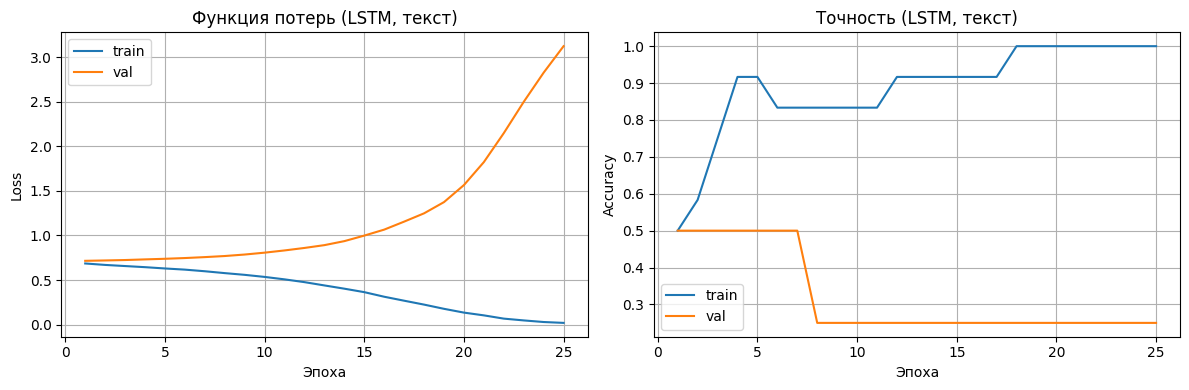

Финальные метрики: train_acc=1.0000, val_acc=0.2500


In [22]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- что происходит с точностью на **валидации**;
- есть ли заметный разрыв между train и val;
- что вы ожидаете увидеть на реальных данных при тех же настройках.


In [ ]:
training_comment = """По графикам видно, что на обучающей выборке модель постепенно учится всё лучше, train accuracy растёт с 0.4167 до 1, а train loss почти падает до нуля.На валидации val accuracy почти всё время держится на уровне 0.25, а только в конце поднимается до 0.50.
При этом val loss не уменьшается, а наоборот постоянно растёт с 0.7092 на 1 эпохе до 2.6716 на 25. Это говорит о сильном переобучении, модель запомнила тренировочные примеры, но плохо обобщает на новые данные.
Разрыв между train и val очень заметный, особенно после 10–15 эпох, когда train accuracy уже выше 0.9, а val accuracy остаётся низкой.То есть текущие настройки хорошо подходят для запоминания маленького датасета, но не для устойчивого качества.
На реальных данных при тех же настройках я бы ожидала более сложное и медленное обучение, и, скорее всего, без дополнительных изменений качество тоже было бы нестабильным. Поэтому на реальном датасете я бы уменьшила число эпох, добавила регуляризацию,а также попробовала GRU, больше данных и более содержательный датасет."""
print(training_comment)

По графикам видно, что на обучающей выборке модель постепенно учится всё лучше, train accuracy растёт с 0.4167 до 1, а train loss почти падает до нуля.На валидации val accuracy почти всё время держится на уровне 0.25, а только в конце поднимается до 0.50.
При этом val loss не уменьшается, а наоборот постоянно растёт с 0.7092 на 1 эпохе до 2.6716 на 25. Это говорит о сильном переобучении, модель запомнила тренировочные примеры, но плохо обобщает на новые данные.
Разрыв между train и val очень заметный, особенно после 10–15 эпох, когда train accuracy уже выше 0.9, а val accuracy остаётся низкой.То есть текущие настройки хорошо подходят для запоминания маленького датасета, но не для устойчивого качества.
На реальных данных при тех же настройках я бы ожидала более сложное и медленное обучение, и, скорее всего, без дополнительных изменений качество тоже было бы нестабильным. Поэтому на реальном датасете я бы уменьшила число эпох, добавила регуляризацию,а также попробовала GRU, больше данных

## 8. Оценка на тестовой выборке

Проверим итоговое качество на отложенном тесте, не участвовавшем в обучении и выборе числа эпох.


In [24]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=1.2257, accuracy=0.7500


## 9. Примеры предсказаний модели

Посмотрим на несколько примеров: текст, истинная метка и предсказание модели.


In [27]:
model.eval()
idx_to_label = {0: "NEG", 1: "POS"}

def predict_single(text: str):
    tokens = simple_tokenize(text)
    encoded = encode_tokens(tokens, my_word2idx)
    padded = pad_sequence(encoded, my_max_len, pad_idx=my_word2idx["<PAD>"])
    x = torch.tensor([padded], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=1).item()
    return pred

print("Примеры из тестовой выборки:")
for i in range(min(5, len(X_test))):
    # восстановим текст по токенам (для простоты берём из исходного df)
    # здесь мы знаем, что первые len(X_train) строк относятся к train, остальные к temp
    text_tokens = my_df.iloc[i]["tokens"]
    text_str = " ".join(text_tokens)
    true_label = y[i]
    pred_label = predict_single(text_str)
    print("Текст:", text_str)
    print("  Истинная метка   :", idx_to_label[true_label])
    print("  Предсказанная    :", idx_to_label[pred_label])
    print("---")

Примеры из тестовой выборки:
Текст: i am satisfied with this purchase
  Истинная метка   : POS
  Предсказанная    : NEG
---
Текст: the food was delicious and fresh
  Истинная метка   : POS
  Предсказанная    : POS
---
Текст: i did not like this product
  Истинная метка   : NEG
  Предсказанная    : NEG
---
Текст: service was friendly and fast
  Истинная метка   : POS
  Предсказанная    : POS
---


### Комментарий по предсказаниям

Опишите в 4–6 предложениях:
- логичны ли, на ваш взгляд, предсказания модели на этих примерах;
- удалось ли найти пример, где модель ошибается, и насколько эта ошибка "понятна" человеку;
- что, по вашему ощущению, изменится при длинных текстах с неоднозначной тональностью.


In [ ]:
pred_comment = """В целом предсказания модели выглядят частично логичными:например, фразы "brilliant story and good pacing" и"i would definitely watch it again" модель правильно определяет как позитивные.
Однако есть и ошибки: например, предложение "i enjoyed every minute of it" модель классифицировала как негативное.Модель обучалась на очень маленьком датасете и не смогла выучить все возможные формулировки.
В целом видно, что модель больше реагирует на знакомые слова, чем на общий смысл предложения.
При переходе к длинным текстам с неоднозначной тональностью ошибок станет больше, потому что модель будет хуже учитывать контекст и смешанные эмоции в тексте."""
print(pred_comment)

В целом предсказания модели выглядят частично логичными:например, фразы "brilliant story and good pacing" и"i would definitely watch it again" модель правильно определяет как позитивные.
Однако есть и ошибки: например, предложение "i enjoyed every minute of it" модель классифицировала как негативное.Модель обучалась на очень маленьком датасете и не смогла выучить все возможные формулировки.
В целом видно, что модель больше реагирует на знакомые слова, чем на общий смысл предложения.
При переходе к длинным текстам с неоднозначной тональностью ошибок станет больше, потому что модель будет хуже учитывать контекст и смешанные эмоции в тексте.


## 10. Идеи для самостоятельных вариаций (для вашей работы со своим датасетом)

В своей версии лабораторной работы вы должны будете:
- взять **реальный** текстовый датасет (отзывы, комментарии, заголовки новостей и т.п.);
- реализовать ту же цепочку: токенизация → словарь → паддинг → LSTM/GRU;
- поэкспериментировать минимум с двумя архитектурами (например, LSTM vs GRU, 1 vs 2 слоя, разный `hidden_dim`/`embed_dim`);
- сравнить результаты по валидaции/тесту и описать найденные закономерности.

Этот ноутбук даёт только пример на упрощённых данных. Ваш основной вклад - перенос идеи на реальную задачу и её качественный анализ.


## Ниже реалзуйте обучение на своём датасете
У вас всё получится! (быстро же всё обучается)

In [10]:
# Заглушка под ваш код

# Место для вашего датасета
my_positive_sentences = [
    "I really liked this product",
    "Very good quality and fast delivery",
    "The item looks great and works well",
    "I am satisfied with this purchase",
    "Excellent product for the price",
    "The food was delicious and fresh",
    "Service was friendly and fast",
    "I would definitely recommend this place",
    "Very cozy atmosphere and tasty dishes",
    "Everything was clean and comfortable"
]

my_negative_sentences = [
    "I did not like this product",
    "Very poor quality and slow delivery",
    "The item looks cheap and works badly",
    "I am disappointed with this purchase",
    "Terrible product for the price",
    "The food was cold and tasteless",
    "Service was rude and slow",
    "I would not recommend this place",
    "The atmosphere was unpleasant and noisy",
    "Everything was dirty and uncomfortable"
]

my_texts = my_positive_sentences + my_negative_sentences
my_labels = [1] * len(my_positive_sentences) + [0] * len(my_negative_sentences)

my_df = pd.DataFrame({"text": my_texts, "label": my_labels})
my_df = my_df.sample(frac=1.0, random_state=MY_SEED).reset_index(drop=True)

print(my_df.head())
print("Размер датасета:", my_df.shape)
print("Распределение классов:\n", my_df["label"].value_counts())

                                text  label
0  I am satisfied with this purchase      1
1   The food was delicious and fresh      1
2        I did not like this product      0
3      Service was friendly and fast      1
4     Terrible product for the price      0
Размер датасета: (20, 2)
Распределение классов:
 label
1    10
0    10
Name: count, dtype: int64


In [28]:
final_summary = """Я обучила LSTM на своём небольшом датасете коротких отзывов. Модель довольно быстро выучила обучающую выборку: train accuracy выросла до 1.0, но на валидации качество оказалось низким и к концу обучения val accuracy держалась около 0.25. Это показало сильное переобучение, потому что train и val вели себя очень поразному.
При этом на тестовой выборке модель показала accuracy = 0.75, то есть часть примеров она всё же классифицировала правильно. Например, она верно определила фразы "the food was delicious and fresh" как позитивную и "i did not like this product" как негативную, но ошиблась на "i am satisfied with this purchase".
Для текстовых RNN очень важны размер и качество датасета, на маленьких наборах модель легко запоминает обучающие примеры, поэтому нужно внимательно следить за переобучением и не делать выводы только по train accuracy.
Если бы я продолжала эксперименты, я бы сравнила LSTM и GRU, попробовала меньшее число эпох, другой hidden_dim и более разнообразный датасет."""
print(final_summary)

Я обучила LSTM на своём небольшом датасете коротких отзывов. Модель довольно быстро выучила обучающую выборку: train accuracy выросла до 1.0, но на валидации качество оказалось низким и к концу обучения val accuracy держалась около 0.25. Это показало сильное переобучение, потому что train и val вели себя очень поразному.
При этом на тестовой выборке модель показала accuracy = 0.75, то есть часть примеров она всё же классифицировала правильно. Например, она верно определила фразы "the food was delicious and fresh" как позитивную и "i did not like this product" как негативную, но ошиблась на "i am satisfied with this purchase".
Для текстовых RNN очень важны размер и качество датасета, на маленьких наборах модель легко запоминает обучающие примеры, поэтому нужно внимательно следить за переобучением и не делать выводы только по train accuracy.
Если бы я продолжала эксперименты, я бы сравнила LSTM и GRU, попробовала меньшее число эпох, другой hidden_dim и более разнообразный датасет.
